In [ ]:
child--cycle
mentor--child-- nhi 


In [3]:
import gymnasium as gym

In [2]:
pip install gymnasium

   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---------------------------------------- 0.0/953.9 kB ? eta -:--:--
   ---

In [5]:
import numpy as np
import random
import matplotlib.pyplot as plt

env=gym.make("FrozenLake-v1",is_slippery=False)

In [10]:
print("States",env.observation_space.n)
print("Action",env.action_space.n)

States 16
Action 4


In [11]:
q_table=np.zeros((16,4))
print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [12]:
lr=0.8
discount_factor=0.95
epslism=1.00
epsilon_d=0.995
min_eps=0.01
episode=1000
max_step=100

In [18]:
rewards = []

for episod in range(episode):
    state, info = env.reset()
    total_reward = 0
    done = False

    for step in range(max_step):

        # Epsilon-greedy action selection
        if random.uniform(0, 1) < epslism:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        # Q-learning update
        old_value = q_table[state, action]
        next_max = np.max(q_table[next_state])

        new_value = old_value + lr * (
            reward + discount_factor * next_max - old_value
        )
        q_table[state, action] = new_value

        state = next_state
        total_reward += reward

        if done:
            break

    # Decay epsilon after each episode
    epslism = max(min_eps, epslism * epsilon_d)

    # Store episode reward
    rewards.append(total_reward)

In [19]:
print(q_table)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


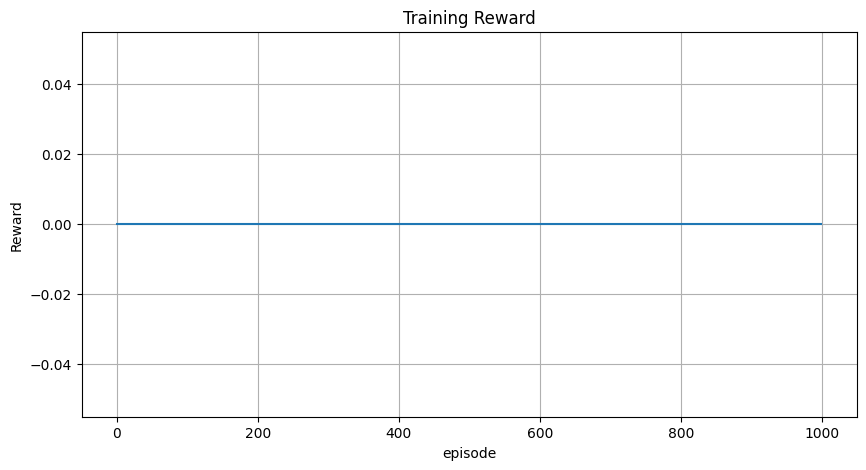

In [20]:
plt.figure(figsize=(10,5))
plt.plot(rewards)
plt.xlabel("episode")
plt.ylabel("Reward")
plt.title("Training Reward")
plt.grid("True")
plt.show()